# Manufacturing Demand Forecast - Modeling

**Project:** Product_Code × Warehouse Demand Forecasting + Inventory Policy Optimization  
**Dataset:** Kaggle Product Demand Forecasting (felixzhao)  
**Forecast Horizon:** 28 days (monthly)  
**CV Strategy:** Fixed-origin rolling window - 3 folds across Q1 2016

---

### Modeling Strategy by Demand Segment (Syntetos-Boylan)

| Demand Type | % of Product_Code × Warehouse | Method |
|---|---|---|
| Smooth | 22% | LightGBM |
| Erratic | 24% | LightGBM |
| Intermittent | 7% | Croston's Method (SBA variant) |
| Lumpy | 47% | Safety stock buffer - conservative demand estimate |

### Key Data Decisions

| Decision | Rationale |
|---|---|
| Drop null `Date` rows from `Whse_A` | MAR classification, 4.5% of Whse_A rows - insignificant |
| Drop parenthesized `Order_Demand` values | Order cancellations - not demand signal |
| Filter to `Order_Demand > 0` | Zero demand rows uninformative for forecasting |
| Aggregate to monthly periods | Matches forecast horizon and Syntetos-Boylan classification granularity |
| Exclude `Category_019` from LightGBM pipeline | Demand volumes 100x greater than remainder of portfolio (median 18,000, max 10.45M, p99/median ratio 123x). Handled separately in production; incompatible with a general ML pipeline |
| One-hot encode `Warehouse` and `demand_type` | Only 4 categories each - avoids implying ordinal relationship |

## Imports & Configuration

In [ ]:
import pandas as pd
import numpy as np
import os
import lightgbm as lgb
import matplotlib.pyplot as plt
import warnings
from dateutil.relativedelta import relativedelta
from sklearn.metrics import mean_squared_error, mean_absolute_error
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from intermittent_forecast.forecasters import Croston

import random
random.seed(42)
np.random.seed(42)

pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')

RAW_DATA_PATH = os.path.expanduser(
    '~/Desktop/data_science/projects/manufacturing_demand_forecast/data/raw/Historical Product Demand.csv'
)
TRAIN_CUTOFF = '2016-01-01'
TEST_CUTOFF  = '2016-07-01'

c:\Users\darre\Desktop\data_science\projects\manufacturing_demand_forecast\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Preparation

All cleaning decisions are documented in the header. The output of this section is `df_monthly`: a clean monthly demand dataframe with Syntetos-Boylan demand type labels attached to every row.

In [2]:
raw_df = pd.read_csv(RAW_DATA_PATH, parse_dates=['Date'])
print(f'Raw data shape: {raw_df.shape}')

df_monthly = (
    raw_df[~raw_df.Order_Demand.str.contains('\(')] # drop order cancellations
    .dropna(subset=['Date']) # drop null Whse_A dates (MAR, 4.5%)
    .assign(Order_Demand=lambda df_: df_.Order_Demand.astype(int))
    .groupby([
        'Product_Code',
        'Warehouse', 
        'Product_Category',
        raw_df['Date'].dt.to_period('M').dt.to_timestamp()
    ])
    .Order_Demand.sum()
    .reset_index()
)
df_monthly = df_monthly[df_monthly.Order_Demand > 0].reset_index(drop=True)

print(f'Cleaned monthly data shape: {df_monthly.shape}')
df_monthly.head()

Raw data shape: (1048575, 5)
Cleaned monthly data shape: (135661, 5)


,Product_Code,Warehouse,Product_Category,Date,Order_Demand
0,Product_0001,Whse_A,Category_005,2012-01-01,6400
1,Product_0001,Whse_A,Category_005,2012-02-01,10400
2,Product_0001,Whse_A,Category_005,2012-03-01,11000
3,Product_0001,Whse_A,Category_005,2012-04-01,1500
4,Product_0001,Whse_A,Category_005,2012-05-01,8000


### Syntetos-Boylan Demand Classification

In [3]:
# Syntetos-Boylan demand classification per product × warehouse
# ADI = total_months / months_with_nonzero_demand (measures intermittency)
# CV**2 = (std / mean)**2 of nonzero demand (measures lumpiness)
# Thresholds: ADI=1.32, CV**2=0.49 (Syntetos & Boylan, 2005)

# calculate ADI and CV2 for every Product_Code x Warehouse
pw_monthly = (
    df_monthly
    .groupby(['Product_Code', 'Warehouse', df_monthly.Date.dt.to_period('M')])
    .Order_Demand.sum()
    .reset_index()
)

delta = relativedelta(df_monthly.Date.max(), df_monthly.Date.min())
total_months = delta.years * 12 + delta.months

months_with_demand = (
    pw_monthly[pw_monthly.Order_Demand > 0]
    .groupby(['Product_Code', 'Warehouse'])
    .agg(Months_Nonzero_Demand=('Date', 'nunique'))
)

nonzero_stats = (
    pw_monthly[pw_monthly.Order_Demand > 0]
    .merge(months_with_demand, on=['Product_Code', 'Warehouse'], how='left')
    .groupby(['Product_Code', 'Warehouse'])
    .agg(
        Nonzero_Demand_std=('Order_Demand','std'),
        Nonzero_Demand_mean=('Order_Demand','mean'),
        Months_Nonzero_Demand=('Months_Nonzero_Demand','first')
    )
    .reset_index()
)
# single-observation products have NaN std - set to 0 (no variability observed)
nonzero_stats['Nonzero_Demand_std'] = nonzero_stats['Nonzero_Demand_std'].fillna(0)

pw_demand_types = nonzero_stats.assign(
    ADI=lambda df_: total_months / df_.Months_Nonzero_Demand,
    CV2=lambda df_: (df_.Nonzero_Demand_std / df_.Nonzero_Demand_mean)**2
)
# create demand_type column
conditions = [
    (pw_demand_types.ADI <  1.32) & (pw_demand_types.CV2 <  0.49), # smooth
    (pw_demand_types.ADI <  1.32) & (pw_demand_types.CV2 >= 0.49), # erratic
    (pw_demand_types.ADI >= 1.32) & (pw_demand_types.CV2 <  0.49), # intermittent
    (pw_demand_types.ADI >= 1.32) & (pw_demand_types.CV2 >= 0.49), # lumpy
]
choices = ['smooth', 'erratic', 'intermittent', 'lumpy']
pw_demand_types['demand_type'] = np.select(conditions, choices, default='unknown')
# merge into modeling DF
df_monthly = df_monthly.merge(
    pw_demand_types[['Product_Code', 'Warehouse', 'demand_type']],
    on=['Product_Code', 'Warehouse'], 
    how='left'
)

print('Demand type distribution:')
(
    df_monthly
    .drop_duplicates(['Product_Code', 'Warehouse'])
    .demand_type
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .to_frame('pct')
)

Demand type distribution:


,pct
demand_type,
lumpy,46.8
erratic,24.0
smooth,22.1
intermittent,7.2


## Feature Engineering

All lag and rolling features use `.shift(1)` before the rolling window to prevent data leakage. The model never sees current-period demand when predicting current-period demand.

In [4]:
# Time features
df_monthly['month'] = df_monthly.Date.dt.month
df_monthly['quarter'] = df_monthly.Date.dt.quarter
df_monthly['year'] = df_monthly.Date.dt.year

# Lag features (per Product_Code × Warehouse)
df_monthly = df_monthly.sort_values(['Product_Code', 'Warehouse', 'Date'])

for lag in [1, 2, 3, 6, 12]:
    df_monthly[f'demand_lag{lag}'] = (
        df_monthly
        .groupby(['Product_Code', 'Warehouse'])
        .Order_Demand
        .shift(lag)
    )

# Rolling statistics (per SKU × warehouse)
# .shift(1) before rolling prevents leakage
for window in [3, 6, 12]:
    df_monthly[f'demand_rolling_mean_{window}m'] = (
        df_monthly
        .groupby(['Product_Code', 'Warehouse'])
        .Order_Demand
        .transform(lambda x: x.shift(1).rolling(window).mean())
    )
    df_monthly[f'demand_rolling_std_{window}m'] = (
        df_monthly
        .groupby(['Product_Code', 'Warehouse'])
        .Order_Demand
        .transform(lambda x: x.shift(1).rolling(window).std())
    )

# One-hot encode Warehouse and demand_type
# One-hot preferred over label encoding for non-ordinal categoricals with few levels
warehouse_dummies = pd.get_dummies(df_monthly.Warehouse, prefix='Warehouse').astype(int)
demand_type_dummies = pd.get_dummies(df_monthly.demand_type, prefix='demand_type').astype(int)

df_monthly = pd.concat([df_monthly, warehouse_dummies, demand_type_dummies], axis=1)

print(f'Feature DF Shape: {df_monthly.shape}')
df_monthly.head()

Feature DF Shape: (135661, 28)


,Product_Code,Warehouse,Product_Category,Date,Order_Demand,demand_type,month,quarter,year,demand_lag1,demand_lag2,demand_lag3,demand_lag6,demand_lag12,demand_rolling_mean_3m,demand_rolling_std_3m,demand_rolling_mean_6m,demand_rolling_std_6m,demand_rolling_mean_12m,demand_rolling_std_12m,Warehouse_Whse_A,Warehouse_Whse_C,Warehouse_Whse_J,Warehouse_Whse_S,demand_type_erratic,demand_type_intermittent,demand_type_lumpy,demand_type_smooth
0,Product_0001,Whse_A,Category_005,2012-01-01,6400,smooth,1,1,2012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,0,0,0,0,1
1,Product_0001,Whse_A,Category_005,2012-02-01,10400,smooth,2,1,2012,6400.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,0,0,0,0,1
2,Product_0001,Whse_A,Category_005,2012-03-01,11000,smooth,3,1,2012,10400.0,6400.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,0,0,0,0,1
3,Product_0001,Whse_A,Category_005,2012-04-01,1500,smooth,4,2,2012,11000.0,10400.0,6400.0,NaN,NaN,9266.666667,2500.666578,NaN,NaN,NaN,NaN,1,0,0,0,0,0,0,1
4,Product_0001,Whse_A,Category_005,2012-05-01,8000,smooth,5,2,2012,1500.0,11000.0,10400.0,NaN,NaN,7633.333333,5320.087719,NaN,NaN,NaN,NaN,1,0,0,0,0,0,0,1


## Train / Validation / Test Split  
Date ranges chosen to give enough data to all three splits.

In [5]:
# Time-based split. no random shuffling
# Train: 2011-01-01 -> 2015-12-01 
# Validation: 2016-01-01 -> 2016-06-01 (CV folds) 
# Test: 2016-07-01 -> 2017-01-01 (held out)

train_df = df_monthly[df_monthly.Date < TRAIN_CUTOFF].copy()
valid_df = df_monthly[(df_monthly.Date >= TRAIN_CUTOFF) & (df_monthly.Date < TEST_CUTOFF)].copy()
test_df = df_monthly[df_monthly.Date >= TEST_CUTOFF].copy()

print(f'Train: {train_df.Date.min().date()} -> {train_df.Date.max().date()} ({len(train_df):,} rows)')
print(f'Valid: {valid_df.Date.min().date()} -> {valid_df.Date.max().date()} ({len(valid_df):,} rows)')
print(f'Test: {test_df.Date.min().date()} -> {test_df.Date.max().date()} ({len(test_df):,} rows)')

Train: 2011-01-01 -> 2015-12-01 (108,596 rows)
Valid: 2016-01-01 -> 2016-06-01 (13,267 rows)
Test: 2016-07-01 -> 2017-01-01 (13,798 rows)


## Feature Columns

In [6]:
# product_code_warehouse_encoded was explored but removed
# target-encoded product mean dominated feature importance (~20x next feature)
# causing the model to memorize historical averages rather than learning demand patterns

feature_cols = [
    # Time
    'month', 'quarter', 'year',
    # Lags
    'demand_lag1', 'demand_lag2', 'demand_lag3', 'demand_lag6', 'demand_lag12',
    # Rolling statistics
    'demand_rolling_mean_3m',  'demand_rolling_std_3m',
    'demand_rolling_mean_6m',  'demand_rolling_std_6m',
    'demand_rolling_mean_12m', 'demand_rolling_std_12m',
    # Warehouse (one-hot)
    'Warehouse_Whse_A', 'Warehouse_Whse_C', 'Warehouse_Whse_J', 'Warehouse_Whse_S',
    # Demand type (one-hot)
    'demand_type_erratic', 'demand_type_intermittent',
    'demand_type_lumpy',   'demand_type_smooth',
]

print(f'{len(feature_cols)} features defined')

22 features defined


## Rolling Window CV Folds

In [7]:
# fixed-origin CV: training data is fixed at everything before TRAIN_CUTOFF
# validation window moves across 2016 Q1. Three 1-month windows spaced evenly
# this matches the 1-month forecast horizon used in the inventory policy layer

folds = [
    ('2016-01-01', '2016-01-31'),
    ('2016-02-01', '2016-02-28'),
    ('2016-03-01', '2016-03-31'),
]

## Baselines

Two baselines evaluated across all CV folds before any segment-specific modeling. Both LightGBM and Croston's method must beat these.

In [8]:
baseline_results = []

for baseline_name in ['demand_lag1','demand_rolling_mean_3m']:
    for fold in folds:
        val_fold = valid_df[(valid_df.Date >= pd.Timestamp(fold[0])) & (valid_df.Date <= pd.Timestamp(fold[1]))].copy()

        preds = val_fold[baseline_name]
        actuals = val_fold.Order_Demand
        mask = preds.notna() & actuals.notna() & (actuals > 0)

        rmse = np.sqrt(mean_squared_error(actuals[mask], preds[mask]))
        mae = mean_absolute_error(actuals[mask], preds[mask])

        baseline_results.append({
            'baseline':baseline_name, 
            'fold':fold[0],
            'segment':'all',
            'rmse':rmse, 
            'mae':mae
        })

        for segment in valid_df.demand_type.unique():
            seg = val_fold[val_fold.demand_type == segment]
            seg_mask = seg[baseline_name].notna() & (seg.Order_Demand > 0)
            if seg_mask.sum() == 0:
                continue
            baseline_results.append({
                'baseline':baseline_name, 
                'fold': fold[0], 
                'segment': segment,
                'rmse':np.sqrt(mean_squared_error(seg.Order_Demand[seg_mask], seg[baseline_name][seg_mask])),
                'mae':mean_absolute_error(seg.Order_Demand[seg_mask], seg[baseline_name][seg_mask]),
            })

baseline_df = pd.DataFrame(baseline_results)
(
    baseline_df.groupby(['baseline', 'segment'])
    [['rmse', 'mae']]
    .agg(['mean', 'std'])
    .round(0)
)

rmse               mae        
                                         mean      std     mean     std
baseline               segment                                         
demand_lag1            all            90313.0   4509.0  16459.0  1049.0
                       erratic       123901.0  15725.0  21305.0  1302.0
                       intermittent   11945.0   2498.0   4859.0   943.0
                       lumpy          16679.0    307.0   3698.0   394.0
                       smooth        109844.0   9499.0  30063.0  4498.0
demand_rolling_mean_3m all            71228.0   7376.0  13806.0  1398.0
                       erratic        81227.0  27506.0  15811.0  3700.0
                       intermittent    9737.0   1957.0   4086.0   495.0
                       lumpy          13651.0   1519.0   3166.0   435.0
                       smooth        101055.0  10106.0  27224.0  3386.0

### Key Findings

**Baseline targets for LightGBM (rolling 3-month mean = best baseline):**

| Segment | RMSE | MAE |
|---|---|---|
| All | 71,228 | 13,806 |
| Smooth | 101,055 | 27,224 |
| Erratic | 81,227 | 15,811 |
| Intermittent | 9,737 | 4,086 |
| Lumpy | 13,651 | 3,166 |

- **Baseline Comparison:** The rolling 3-month mean beating the 1-month lag means a longer look back in time at demand predicts better than a shorter one (in this case 3-month versus 1-month). However, it is possible that other rolling windows or lags that weren't explored are better baselines.
- **What the aggregate metrics hid vs demand type segment metrics:** Smooth demand products have the highest absolute errors, but that is because they have much higher volumes. Intermittent demand products have lower absolute errors, but are still more difficult to model on a percentage-error basis than smooth or erratic because of their inherent demand profile. If a percentage error metric was used it would re-frame the performance between segments.
    - **Lumpy demand types:** Lumpy demand profiles are inherently difficult to model. While they are in the baseline metrics table, they will be handled with an inventory policy layer designed to absorb their uncertainty with safety stock.
    - **Smooth demand type RMSE:** Smooth demand types have the highest absolute RMSE despite having the most robust demand profiles. This is most likely due to high-volume products driving the smooth demand segment.
- **How this affects modeling decisions:** If more advanced methods cannot meaningfully beat the rolling 3-month mean, the simpler baseline is preferred. Complexity should be justified by measurable improvement.

## LightGBM for Smooth/Erratic Segments

### Default LightGBM for Smooth/Erratic Segments

#### Category_019 Exclusion

During initial LightGBM training, Category_019 was identified as incompatible with a general ML pipeline:
- Median demand: 18,000 units | Max: 10.45M units | p99/median ratio: 123x | Skewness: 9.20
- Demand volumes 100x greater than remainder of portfolio
- Extreme internal heterogeneity. A dedicated model would be required in production

**Decision:** Exclude Category_019 from the LightGBM pipeline. Document as a production extension.

#### Target-Encoded Product_Code x Warehouse Feature Exclusion

A `product_code_warehouse_encoded` feature (mean demand per product × warehouse) was explored but removed. Feature importance analysis showed it dominated gain by ~20x, causing the model to memorize historical averages rather than learn demand patterns from lag and rolling features. Removing it improved model behavior and interpretability.

In [9]:
# Filter to smooth + erratic segments, exclude Category_019
lgbm_segments = ['smooth', 'erratic']

lgbm_train = (
    train_df[
        (train_df.demand_type.isin(lgbm_segments))
        &(train_df.Product_Category != 'Category_019')
    ]
    .dropna(subset=[
        'demand_lag1',
        'demand_lag2',
        'demand_lag3',
        'demand_rolling_mean_3m',
        'demand_rolling_std_3m'
    ])
    .copy()
)

lgbm_valid = (
    valid_df[
        (valid_df.demand_type.isin(lgbm_segments))
        &(valid_df.Product_Category != 'Category_019')
    ]
    .copy()
)

print(f'LGBM train: {len(lgbm_train):,} rows')
print(f'LGBM valid: {len(lgbm_valid):,} rows')
print(f'Train nulls in feature_cols: {lgbm_train[feature_cols].isnull().sum().sum():,}')

LGBM train: 38,391 rows
LGBM valid: 5,031 rows
Train nulls in feature_cols: 31,248


#### Training null values
- Nulls are focused in the longer lookback features (12 months/6 months), not in the more recent training data (3 months, 1 month)
- LightGBM should handle these natively

In [10]:
lgbm_train[feature_cols].isnull().sum().sort_values(ascending=False)

demand_rolling_std_12m      7812
demand_lag12                7812
demand_rolling_mean_12m     7812
demand_rolling_std_6m       2604
demand_lag6                 2604
demand_rolling_mean_6m      2604
demand_type_lumpy              0
demand_type_intermittent       0
demand_type_erratic            0
Warehouse_Whse_S               0
Warehouse_Whse_J               0
Warehouse_Whse_C               0
Warehouse_Whse_A               0
month                          0
quarter                        0
demand_rolling_std_3m          0
demand_rolling_mean_3m         0
demand_lag3                    0
demand_lag2                    0
demand_lag1                    0
year                           0
demand_type_smooth             0
dtype: int64

In [11]:
# Determine optimal num_boost_round using fold 1 validation as early stopping monitor
# Training on full lgbm_train preserves all historical signal

params = {
    'objective':'regression',
    'metric':'rmse',
    'verbose':-1,
    'seed': 42
}

es_val = lgbm_valid[
    (lgbm_valid.Date >= '2016-01-01')
    &(lgbm_valid.Date <= '2016-01-31')
]

dtrain = lgb.Dataset(lgbm_train[feature_cols], label=np.log1p(lgbm_train.Order_Demand))
dmonitor = lgb.Dataset(es_val[feature_cols], label=np.log1p(es_val.Order_Demand), reference=dtrain)

model_es = lgb.train(
    params, 
    dtrain,
    num_boost_round=1000,
    valid_sets=[dmonitor],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)],
)

best_rounds = model_es.best_iteration
print(f'Best rounds: {best_rounds}')

Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 1.01593
Early stopping, best iteration is:
[100]	valid_0's rmse: 1.01593
Best rounds: 100


In [1]:
build_docker_image = "docker build -t manufacturing-demand-forecast ."
build_docker_image.split(" ")

['docker', 'build', '-t', 'manufacturing-demand-forecast', '.']

In [12]:
# CV loop: fixed num_boost_round from early stopping above
lgbm_results = []

for fold in folds:
    val_fold = lgbm_valid[
        (lgbm_valid.Date >= pd.Timestamp(fold[0]))
        &(lgbm_valid.Date <= pd.Timestamp(fold[1]))
    ].copy()

    if len(val_fold) == 0:
        continue

    model_cv = lgb.train(
        params, 
        dtrain,
        num_boost_round=best_rounds,
    )

    preds = np.expm1(model_cv.predict(val_fold[feature_cols]))
    val_fold['preds'] = preds
    actuals = val_fold.Order_Demand.values
    mask = actuals > 0

    lgbm_results.append({
        'fold':fold[0], 
        'segment':'all',
        'rmse':np.sqrt(mean_squared_error(actuals[mask], preds[mask])),
        'mae':mean_absolute_error(actuals[mask], preds[mask]),
        'bias':np.mean(preds[mask] - actuals[mask]),
    })

    for segment in lgbm_segments:
        seg = val_fold[val_fold.demand_type == segment]
        seg_mask = seg.Order_Demand > 0
        if seg_mask.sum() == 0:
            continue
        lgbm_results.append({
            'fold':fold[0], 
            'segment':segment,
            'rmse':np.sqrt(mean_squared_error(seg.Order_Demand[seg_mask], seg.preds[seg_mask])),
            'mae':mean_absolute_error(seg.Order_Demand[seg_mask], seg.preds[seg_mask]),
            'bias':np.mean(seg.preds[seg_mask] - seg.Order_Demand[seg_mask]),
        })

lgbm_df = pd.DataFrame(lgbm_results)
(
    lgbm_df
    .groupby('segment')
    [['rmse','mae','bias']]
    .agg(['mean','std'])
    .round(0)
)

rmse               mae            bias        
            mean      std     mean     std    mean     std
segment                                                   
all      30581.0   7309.0   5898.0   690.0 -1036.0  1679.0
erratic  22872.0   8434.0   2972.0   383.0  -524.0  1429.0
smooth   38078.0  11770.0  10063.0  1813.0 -1764.0  2663.0

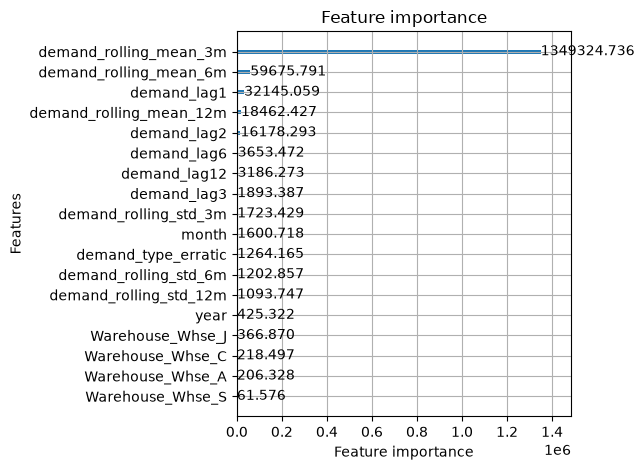

In [ ]:
lgb.plot_importance(model_cv, max_num_features=20, importance_type='gain')
plt.tight_layout()
plt.show()

#### Default Model Key Findings
- Default LGBM improved over baseline significantly, especially for erratic demand segments (81% improvement)
- Smooth RMSE > Erratic RMSE: most likely a volume effect from smooth demand types having more regular demand
- Bias is small and negative for both demand types: the model slightly under-forecasts
- STD for Erratic demand type is narrow (+- 8,434) compared to smooth (+- 11,770). This goes against the logic that erratic demand is harder to predict than smooth demand.

| Demand Type | Baseline MAE | Default LightGBM MAE | Improvement |
| --- | --- | --- | --- |
| Smooth | 27,224 | 10,063 | 63% |
| Erratic | 15,811 | 2,972 | 81% |
| Both | 13,806 | 5,898 | 57% |

### Tuned LightGBM for Smooth/Erratic Segments
- Using optuna for parameter search
- Same exclusions for `Category_019` and `product_code_warehouse_encoded` as before.

#### Parameter Search

In [13]:
def objective(trial):
    params = {
        'objective':'regression',
        'metric':'rmse',
        'verbose':-1,
        'learning_rate':trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves':trial.suggest_int('num_leaves', 20, 150),
        'min_child_samples':trial.suggest_int('min_child_samples', 10, 100),
        'feature_fraction':trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction':trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq':trial.suggest_int('bagging_freq', 1, 10),
        'lambda_l1':trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2':trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
    }
    # rebuild dtrain inside the objective to avoid feature pre-filter caching conflict
    dtrain_trial = lgb.Dataset(lgbm_train[feature_cols], label=np.log1p(lgbm_train['Order_Demand']))

    fold_rmses = []
    for fold in folds:
        val_fold = lgbm_valid[(lgbm_valid.Date >= pd.Timestamp(fold[0])) & (lgbm_valid.Date <= pd.Timestamp(fold[1]))].copy()

        if len(val_fold) == 0:
            continue

        model_cv = lgb.train(
            params,
            dtrain_trial,
            num_boost_round=best_rounds
        )

        preds = np.expm1(model_cv.predict(val_fold[feature_cols]))
        actuals = val_fold.Order_Demand.values
        mask = actuals > 0

        fold_rmses.append(np.sqrt(mean_squared_error(actuals[mask], preds[mask])))

    return np.mean(fold_rmses)

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest CV RMSE: {study.best_value:,.0f}")
print('Best params:')
for k, v in study.best_params.items():
    print(f" {k}: {v}")

Best trial: 48. Best value: 29236.6: 100%|██████████| 50/50 [00:39<00:00,  1.27it/s]


Best CV RMSE: 29,237
Best params:
 learning_rate: 0.08266383318521064
 num_leaves: 107
 min_child_samples: 19
 feature_fraction: 0.7832119385887515
 bagging_fraction: 0.6234873022059475
 bagging_freq: 10
 lambda_l1: 2.054784109787194e-06
 lambda_l2: 3.2683401224234596


#### Train Model on Best Parameters

In [14]:
best_params = study.best_params
best_params['objective'] = 'regression'
best_params['metric'] = 'rmse'
best_params['verbose'] = -1
best_params['seed'] = 42

# rebuild dtrain w/ best params
dtrain_tuned = lgb.Dataset(lgbm_train[feature_cols], label=np.log1p(lgbm_train.Order_Demand))
dmonitor_tuned = lgb.Dataset(
    es_val[feature_cols],
    label=np.log1p(es_val.Order_Demand),
    reference=dtrain_tuned
)

# find best rounds for tuned params
tuned_es = lgb.train(
    best_params,
    dtrain_tuned,
    num_boost_round=1000,
    valid_sets=[dmonitor_tuned],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)
best_rounds_tuned = tuned_es.best_iteration
print(f"Best rounds (tuned): {best_rounds_tuned}")

# evaluate across CV folds
tuned_results = []

for fold in folds:
    val_fold = lgbm_valid[(lgbm_valid.Date >= pd.Timestamp(fold[0])) & (lgbm_valid.Date <= pd.Timestamp(fold[1]))].copy()

    if len(val_fold) == 0:
        continue

    model_tuned = lgb.train(
        best_params,
        dtrain_tuned,
        num_boost_round=best_rounds_tuned
    )

    preds = np.expm1(model_tuned.predict(val_fold[feature_cols]))
    val_fold['preds'] = preds
    actuals = val_fold.Order_Demand.values
    mask = actuals > 0

    tuned_results.append({
        'fold':fold[0],
        'segment':'all',
        'rmse':np.sqrt(mean_squared_error(actuals[mask], preds[mask])),
        'mae':mean_absolute_error(actuals[mask], preds[mask]),
        'bias':np.mean(preds[mask] - actuals[mask])
    })

    for segment in lgbm_segments:
        seg = val_fold[val_fold.demand_type == segment]
        seg_mask = seg.Order_Demand > 0
        if seg_mask.sum() == 0:
            continue
        tuned_results.append({
            'fold':fold[0],
            'segment':segment,
            'rmse':np.sqrt(mean_squared_error(seg.Order_Demand[seg_mask], seg.preds[seg_mask])),
            'mae':mean_absolute_error(seg.Order_Demand[seg_mask], seg.preds[seg_mask]),
            'bias':np.mean(seg.preds[seg_mask] - seg.Order_Demand[seg_mask])
        })

tuned_df = pd.DataFrame(tuned_results)
(
    tuned_df
    .groupby('segment')
    [['rmse','mae','bias']]
    .agg(['mean','std'])
    .round(0)
)

Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 1.02903
Early stopping, best iteration is:
[59]	valid_0's rmse: 1.01913
Best rounds (tuned): 59


rmse              mae            bias        
            mean      std    mean     std    mean     std
segment                                                  
all      32394.0   7284.0  5783.0   695.0 -2016.0  1938.0
erratic  24031.0   6931.0  2967.0   437.0  -690.0  1375.0
smooth   40336.0  14308.0  9794.0  2124.0 -3904.0  3210.0

#### Tuned Model Key Findings

| Model | RMSE (all) | MAE (all) | Bias |
| --- | --- | --- | --- |
| Tuned LightGBM | 32,394 | 5,783 | -2,016 |
| Default LightGBM | 30,581 | 5,898 | -1,036 |

- The tuned model ended up slightly wose than the default model on RMSE and slightly better on MAE. There is a negligible difference and the default model has less bias. Use the default model.
- The tuned model under-forecasts more than the default model with a bias of -2,016.
- Optuna tuning did not produce a meaningful improvement over default parameters, consistent with LightGBM's well-calibrated defaults on tabular data.

### Overall LightGBM Key Findings

* **Default LightGBM**
   * The default LightGBM model performed much better than the baseline (+63% smooth, +81% erratic, +57% both). The model slightly under-forecasts with a mean bias of -1,036 units.
* **Modeling exclusions**
   * `Category_019` had demand volumes 100x greater than the remainder of the product portfolio, causing poor model performance. It will require it's own analysis and model(s) to properly forecast.
   * Target-encoded `product_code_warehouse_encoded` feature (mean demand per product x warehouse) was removed because it dominated feature importance by approximately 20x. It was causing the model to memorize historical averages rather than learning demand patterns.
* **Tuned vs Default LightGBM**
   * The tuned model performed slightly worse than the default model. Optuna did not produce meaningful improvement over default parameters.
   * LightGBM has well-calibrated defaults for tabular data.
   * The tuned model converged at 55 rounds versus 100 for the default. The interaction between round count and hyperparameters likely explains the divergence.
* **LightGBM vs Baselines:** The default LightGBM outperforms the rolling mean baseline across both smooth and erratic segments and is retained over the tuned model due to comparable performance with lower computational cost.

## Croston's SBA for Intermittent Segments

In [15]:
# fit on training series, forecast on period ahead
# need to convert pandas series to a list or numpy array before passing it into .fit()
# forecast(start, end) uses index positions: start=len(train_series) means "start forecasting from the next period after training ends"
# alpha is optimized automatically
# use SBA variant that corrects vanilla Croston's known bias

intermittent_df = df_monthly[df_monthly.demand_type == 'intermittent']

unique_combos = intermittent_df[['Product_Code','Warehouse']].drop_duplicates()

results = []

for _, row in unique_combos.iterrows():
    # get training series
    train_series = intermittent_df.Order_Demand[
        (intermittent_df.Date < TRAIN_CUTOFF) 
        &(intermittent_df.Warehouse == row['Warehouse'])
        &(intermittent_df.Product_Code == row['Product_Code'])
    ].tolist()
    # fit training series to croston
    if len([x for x in train_series if x != 0]) < 2: # need at least 2 non-zero demand values
        continue
    cro = Croston().fit(ts=train_series, optimisation_metric='MAE', variant='sba')
    forecast = cro.forecast(start=len(train_series), end=len(train_series) + 1)
    for fold in folds:
        # get validation actual
        actuals = intermittent_df.Order_Demand[
            (intermittent_df.Date == pd.Timestamp(fold[0]))
            &(intermittent_df.Warehouse == row['Warehouse'])
            &(intermittent_df.Product_Code == row['Product_Code'])
        ].tolist()
        # skip products with no actual demand in the fold window
        if len(actuals) == 0: 
            continue
        actuals_arr = np.array(actuals)
        forecast_value = forecast[0]
        forecast_arr = np.full_like(actuals_arr, forecast_value, dtype=float)        
        # compare forecast to actual
        rmse = np.sqrt(mean_squared_error(actuals_arr, forecast_arr))
        mae = mean_absolute_error(actuals_arr, forecast_arr)
        bias = np.mean(forecast_arr - actuals_arr)
        # store results
        results.append({
            'fold':fold[0],
            'segment':'intermittent',
            'rmse':rmse,
            'mae':mae,
            'bias':bias
        })

croston_df = pd.DataFrame(results)
(
    croston_df
    .groupby('segment')
    [['rmse','mae','bias']]
    .agg(['mean','std'])
    .round(0)
)

rmse             mae           bias        
                mean     std    mean     std   mean     std
segment                                                    
intermittent  3685.0  8065.0  3685.0  8065.0  381.0  8861.0

### Key Findings

| Model | RMSE | MAE | Bias |
| --- | --- | --- | --- |
| Baseline - rolling 3m mean (intermittent) | 9,737 | 4,086 | --- |
| Croston's (SBA) | 3,685 | 3,685 | 381 |

* **Croston's SBA Variant:** The Syntetos–Boylan Approximation (SBA) is a modified version of Croston’s method designed to correct the positive bias (over-forecasting) inherent in the original 1972 model. SBA applies a bias correction factor of `(1 - alpha/2)` to the vanilla Croston forecast, reducing the systematic over-forecasting documented by Syntetos and Boylan in 2005.
    * A known limitation is that Croston's produces a static forecast after training. It does not adapt to new demand events without retraining.
* **Performance**
    * MAE improved 9.8% over the rolling mean baseline. RMSE = MAE in the Croston results because only one result is being stored per product x fold comparison, making them mathematically identical.
    * The RMSE STD (+- 8,065) is wide relative to mean, but it is an intermittent demand profile which means a noisy demand signal so it is expected. A handful of large demand events will swing the average RMSE significantly.
    * Marginal over-forecasting with a +381 bias is a slightly riskier failure mode for inventory policy than under-forecasting. It suggests safety stock may be slightly inflated, which is acceptable given the low demand frequency for intermittent products.
    * MAE is the right metric because the errors can widely vary in this demand segment, which can cause larger demand swings that increase fold-level RMSE significantly. MAE is more robust in this situation.

## Policy Layer for Lumpy Segments  
The forecast is unreliable for lumpy demand types, so the inventory policy absorbs the uncertainty. A conservative historical mean with a wide safety stock buffer is applied, consistent with common practice for high-variability, low-frequency demand.

1. Conservative demand estimate per lumpy `Product_Code` x `Warehouse`
    - Use the historical mean demand from the training period as the demand estimate
2. Wide safety stock buffer
    - Use a higher Z vaule (ex: 2.33 for 99% service level) to reflect the higher uncertainty

Safety stock formula:
```text
SS = Z × sigma × √L

where:
  Z = service level multiplier
  sigma = standard deviation of demand over the period
  L = lead time in periods (1 month = 1 period)
```

mean_demand = mean of `Order_Demand` in training data  
sigma = std of `Order_Demand` in training data  
ROP = (mean_demand x L) + SS

In [16]:
Z = 2.33 # for 99% service level to reflect the higher uncertainty
L = 1 # monthly data with a forecast horizon of 1 month

lumpy_df = train_df[train_df.demand_type == 'lumpy']
print(f'Training rows with lumpy demand type: {len(lumpy_df):,}')

lumpy_inv_policy = (
    lumpy_df
    .groupby(['Product_Code','Warehouse'])
    .agg(
        mean_demand=('Order_Demand','mean'),
        sigma=('Order_Demand','std')
    )
    .fillna(0) # single-observation products have NaN std - set to 0 (there were 8 products with sigma = 0 and SS = 0)
    .assign(
        SS = lambda df_: Z * df_.sigma * np.sqrt(L),
        ROP = lambda df_: (df_.mean_demand * L) + df_.SS
    )
    .reset_index()
)

print('Output shape:',lumpy_inv_policy.shape)
lumpy_inv_policy.head()

Training rows with lumpy demand type: 41,146
Output shape: (1315, 6)


,Product_Code,Warehouse,mean_demand,sigma,SS,ROP
0,Product_0002,Whse_C,3487.500000,2392.529774,5574.594373,9062.094373
1,Product_0003,Whse_S,415.000000,596.807747,1390.562051,1805.562051
2,Product_0005,Whse_J,600.000000,429.668924,1001.128594,1601.128594
3,Product_0012,Whse_S,20145.833333,14233.597627,33164.282472,53310.115805
4,Product_0024,Whse_J,10534.883721,11260.125258,26236.091850,36770.975571


### Key Findings

* **Inventory policy approach:** 
   * Lumpy demand profiles have high-variability and low-frequency demand. They cannot be reliably forecasted.
   * Due to the demand profile, a conservative historical mean demand estimate is used to determine a wide safety stock buffer. The point is to absorb the uncertainty with a higher service level.
* **Safety stock calculation assumptions:**
   * Z = 2.33 for the 99% service level
   * L = 1 to reflect the monthly data granularity and forecast horizon of one month
   *  mean demand = mean of Order_Demand in training data
   * sigma = standard deviation of Order_Demand in training data
* **Limitations:** This is a safety net method for high-variability/low-frequency demand types. It has higher costs to meet appropriate product service levels. It also assumes you want a 99% service level for these products. It may be more ideal financially to meet a lower service level for some of these products. A sensitivity analysis on Z values would quantify the cost tradeoff between service levels for individual products.

---

## Modeling Summary

**Accomplishments**
- Developed a differentiated inventory policy across four demand segments, covering 66% of training data volume with ML-driven forecasts.
- Applied Syntetos-Boylan demand classification to route products to segment-appropriate forecasting models. LightGBM for smooth and erratic segments (63-81% MAE improvement over baseline), Croston's SBA for intermittent demand (9.8% MAE improvement), and a safety stock buffer for lumpy demand.

**Limitations**
- Category_019 product categories were not modeled in this experiment and require further analysis.
- Lumpy demand products are inherently difficult to forecast reliably. An inventory policy layer using historical mean demand and a 99% service level safety stock buffer was applied instead of a point forecast.

**Production Considerations**
- Demand patterns may shift due to supplier changes, seasonality drift, or new product introductions. A monthly retraining cadence is recommended with data drift monitoring on key lag features.

**Next Steps**
- Evaluate final model performance on the held-out test set: the definitive unbiased performance estimate.
- Develop a dedicated forecasting approach for Category_019 products.

## Test Data Evaluation

### Default LightGBM for Smooth/Erratic Segments

In [17]:
lgbm_test = (
    test_df[
        (test_df.demand_type.isin(lgbm_segments))
        &(test_df.Product_Category != 'Category_019')
    ]
    .copy()
)

print(f'LGBM test: {len(lgbm_test):,} rows')
print(f'Test nulls in feature_cols: {lgbm_test[feature_cols].isnull().sum().sum():,}')

LGBM test: 5,028 rows
Test nulls in feature_cols: 0


In [18]:
lgbm_test_results = []

preds = np.expm1(model_cv.predict(lgbm_test[feature_cols]))
lgbm_test['preds'] = preds
actuals = lgbm_test.Order_Demand.values
mask = actuals > 0

lgbm_test_results.append({
    'segment':'all',
    'rmse':np.sqrt(mean_squared_error(actuals[mask], preds[mask])),
    'mae':mean_absolute_error(actuals[mask], preds[mask]),
    'bias':np.mean(preds[mask] - actuals[mask]),
})

for segment in lgbm_segments:
    seg = lgbm_test[lgbm_test.demand_type == segment]
    seg_mask = seg.Order_Demand > 0
    if seg_mask.sum() == 0:
        continue
    lgbm_test_results.append({
        'segment':segment,
        'rmse':np.sqrt(mean_squared_error(seg.Order_Demand[seg_mask], seg.preds[seg_mask])),
        'mae':mean_absolute_error(seg.Order_Demand[seg_mask], seg.preds[seg_mask]),
        'bias':np.mean(seg.preds[seg_mask] - seg.Order_Demand[seg_mask]),
    })

lgbm_test_df = pd.DataFrame(lgbm_test_results)
(
    lgbm_test_df
    .groupby('segment')
    [['rmse','mae','bias']]
    .agg(['mean'])
    .round(0)
)

,rmse,mae,bias
,mean,mean,mean
segment,,,
all,30552.0,5998.0,-1808.0
erratic,23251.0,3159.0,-995.0
smooth,38508.0,9970.0,-2945.0


#### Key Findings

| Segment | Baseline MAE | CV MAE | Test MAE | CV vs Baseline | Test vs Baseline |
| --- | --- | --- | --- | --- | --- |
| Smooth | 27,224 | 10,063 | 9,970 | 63% | 63% |
| Erratic | 15,811 | 2,972 | 3,159 | 81% | 80% |
| Both | 13,806 | 5,898 | 5,998 | 57% | 57% |

- Test performance nearly identical to CV performance. The model generalized cleanly on unseen data.
- The gap between CV and test is less than 2% on MAE for both segments, which means the CV results were not optimistic.

### Croston's SBA for Intermittent Segments
- Training on all data until `TEST_CUTOFF` because validation data is no longer needed for model selection. This gives Croston's the most recent demand signal before forecasting on the test window.

In [19]:
intermittent_df = df_monthly[df_monthly.demand_type == 'intermittent']

unique_combos = intermittent_df[['Product_Code','Warehouse']].drop_duplicates()

croston_test_results = []

for _, row in unique_combos.iterrows():
    # get training series
    train_series = intermittent_df.Order_Demand[
        (intermittent_df.Date < TEST_CUTOFF) 
        &(intermittent_df.Warehouse == row['Warehouse'])
        &(intermittent_df.Product_Code == row['Product_Code'])
    ].tolist()
    # fit training series to croston
    if len([x for x in train_series if x != 0]) < 2: # need at least 2 non-zero demand values
        continue
    cro = Croston().fit(ts=train_series, optimisation_metric='MAE', variant='sba')
    forecast = cro.forecast(start=len(train_series), end=len(train_series) + 1)

    actuals = intermittent_df.Order_Demand[
        (intermittent_df.Date >= TEST_CUTOFF) 
        &(intermittent_df.Warehouse == row['Warehouse'])
        &(intermittent_df.Product_Code == row['Product_Code'])
    ].tolist()

    if len(actuals) == 0: 
        continue

    actuals_arr = np.array(actuals)
    forecast_value = forecast[0]
    forecast_arr = np.full_like(actuals_arr, forecast_value, dtype=float)        
    # compare forecast to actual
    rmse = np.sqrt(mean_squared_error(actuals_arr, forecast_arr))
    mae = mean_absolute_error(actuals_arr, forecast_arr)
    bias = np.mean(forecast_arr - actuals_arr)
    # store results
    croston_test_results.append({
        'segment':'intermittent',
        'rmse':rmse,
        'mae':mae,
        'bias':bias
    })

croston_test_df = pd.DataFrame(croston_test_results)
(
    croston_test_df
    .groupby('segment')
    [['rmse','mae','bias']]
    .agg(['mean','std'])
    .round(0)
)

rmse              mae           bias        
                mean      std    mean     std   mean     std
segment                                                     
intermittent  5058.0  11368.0  4100.0  9000.0 -817.0  6199.0

#### Key Findings

| Segment | Baseline MAE | CV MAE | Test MAE | Test vs Baseline |
| --- | --- | --- | --- | --- |
| Intermittent | 4,086 | 3,685 | 4,100 | 0.3% |

- Croston's test MAE (4,100) is slightly worse than CV MAE (3,685) - a 11% degradation. This is expected because Croston's produces a static forecast. The further you get from the training window, the less relevant the smoothed estimate becomes. It still beats the baseline.

### Policy Layer for Lumpy Segments
- No predicted demand to compare against actual demand in the traditional sense. The policy output layer is a recommended inventory level, not a demand forecast.

In [20]:
print(f"Lumpy product x warehouse combinations: {len(lumpy_inv_policy):,}")
print(f"\nMean safety stock: {lumpy_inv_policy.SS.mean():,.0f} units")
print(f"Median safety stock: {lumpy_inv_policy.SS.median():,.0f} units")
print(f"\nMean reorder point: {lumpy_inv_policy.ROP.mean():,.0f} units")
print(f"Median reorder point: {lumpy_inv_policy.ROP.median():,.0f} units")

Lumpy product x warehouse combinations: 1,315

Mean safety stock: 10,658 units
Median safety stock: 711 units

Mean reorder point: 14,940 units
Median reorder point: 985 units


In [21]:
lumpy_inv_policy[['SS','ROP']].describe().round().T

,count,mean,std,min,25%,50%,75%,max
SS,1315.0,10658.0,37169.0,0.0,101.0,711.0,4787.0,641062.0
ROP,1315.0,14940.0,51094.0,2.0,147.0,985.0,6745.0,830830.0


### Test Evaluation Summary

| Segment | Method | Baseline MAE | Test MAE | Improvement |
| --- | --- | --- | --- | --- |
| Smooth | LightGBM default | 27,224 | 9,970 | 63% |
| Erratic | LightGBM default | 15,811 | 3,159 | 80% |
| Intermittent | Croston's SBA | 4,086 | 4,100 | 0.3% |
| Lumpy | Safety stock buffer | --- | --- | Policy layer |

- Test performance nearly identical to CV performance. The model generalized cleanly on unseen data.
- The gap between CV and test is less than 2% on MAE for both segments, which means the CV results were not optimistic.
- Croston's test MAE (4,100) is slightly worse than CV MAE (3,685) - a 11% degradation. This is expected because Croston's produces a static forecast. The further you get from the training window, the less relevant the smoothed estimate becomes. It still beats the baseline.
- The safety stock buffer covers 1,315 lumpy product × warehouse combinations with a mean safety stock of 10,658 units and mean reorder point of 14,940 units.

## Save Model

In [ ]:
# model_cv.save_model('../models/lgbm_model.txt')